In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1949_bacteria_4880.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/per

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Updated import
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
import cv2
import os


2025-09-09 22:12:02.517685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757455922.879603      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757455922.978965      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 224
def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
               
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size)) 
                    if resized_arr is not None:  # Check if resize was successful
                        data.append([resized_arr, class_num])
                    else:
                         print(f"Warning: Could not resize image {img}")
                else:
                    print(f"Warning: Could not read image {img}")
            except Exception as e:
                print(f"Error loading image {img}: {e}")
    return np.array(data, dtype=object)

In [6]:
# Paths for each set
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
# Load datasets
train_data = get_training_data(train_dir)

In [7]:
X = np.array([i[0] for i in train_data]).astype("float32") / 255.0
y = np.array([i[1] for i in train_data])

# Split into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [8]:
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3651, 224, 224, 3) (3651,)
Validation shape: (782, 224, 224, 3) (782,)
Test shape: (783, 224, 224, 3) (783,)


In [9]:
# Count samples per class
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(labels, counts))

print("Number of samples per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


Number of samples per class:
PNEUMONIA: 2712
NORMAL: 939


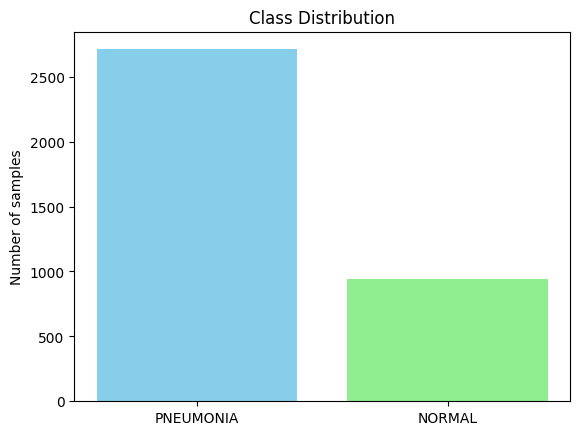

In [10]:
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue', 'lightgreen'])
plt.title("Class Distribution")
plt.ylabel("Number of samples")
plt.show()

In [11]:
normal_indices = np.where(y_train == 1)[0]
normal_images = X_train[normal_indices]
normal_labels = y_train[normal_indices]

In [12]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [13]:
augmented_images = []
augmented_labels = []

for img in normal_images:
    img = np.expand_dims(img, 0)  
    for batch in datagen.flow(img, batch_size=1):
        augmented_images.append(batch[0])
        augmented_labels.append(1)  # NORMAL label
        break  # only 1 augmented copy per original

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

print("Augmented set:", augmented_images.shape, augmented_labels.shape)


Augmented set: (939, 224, 224, 3) (939,)


In [14]:
X_train = X_train.astype('float16')

In [15]:
X_train_aug = np.concatenate((X_train, augmented_images), axis=0)
y_train_aug = np.concatenate((y_train, augmented_labels), axis=0)

print("New training set shape:", X_train_aug.shape, y_train_aug.shape)

New training set shape: (4590, 224, 224, 3) (4590,)


In [16]:
# Count samples per class
unique, counts = np.unique(y_train_aug, return_counts=True)
class_counts = dict(zip(labels, counts))

print("Number of samples per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Number of samples per class:
PNEUMONIA: 2712
NORMAL: 1878


In [17]:
import tensorflow as tf
BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_aug, y_train_aug))
    .shuffle(1000)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


I0000 00:00:1757456061.421419      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757456061.422193      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Load base model
base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze early layers 
for layer in base.layers[:10]:   # freeze first ~2 blocks
    layer.trainable = False


for layer in base.layers[10:]:
    layer.trainable = True

# Build model
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Pneumonia vs Normal
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 13,110,785 (50.01 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [19]:
from tensorflow.keras.callbacks import Callback, EarlyStopping

# Custom callback to stop at 96% val accuracy
class StopAtAccuracy(Callback):
    def __init__(self, acc=0.96):
        super(StopAtAccuracy, self).__init__()
        self.acc = acc

    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= self.acc:
            print(f"\nReached {self.acc*100:.2f}% validation accuracy. Stopping training!")
            self.model.stop_training = True

# Add both EarlyStopping (to avoid overfitting) and custom StopAtAccuracy
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    StopAtAccuracy(acc=0.97)
]


In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15


I0000 00:00:1757456079.023394     102 service.cc:148] XLA service 0x7a5a2c040280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757456079.025341     102 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757456079.025374     102 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757456079.727106     102 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1757456097.421360     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


144/144 ━━━━━━━━━━━━━━━━━━━━ 80s 381ms/step - accuracy: 0.8573 - loss: 0.3095 - val_accuracy: 0.9028 - val_loss: 0.3566
Epoch 2/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 42s 290ms/step - accuracy: 0.9592 - loss: 0.1082 - val_accuracy: 0.9578 - val_loss: 0.1230
Epoch 3/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 44s 309ms/step - accuracy: 0.9786 - loss: 0.0656 - val_accuracy: 0.9604 - val_loss: 0.1056
Epoch 4/15
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9816 - loss: 0.0460
Reached 97.00% validation accuracy. Stopping training!
144/144 ━━━━━━━━━━━━━━━━━━━━ 43s 298ms/step - accuracy: 0.9816 - loss: 0.0460 - val_accuracy: 0.9719 - val_loss: 0.0855


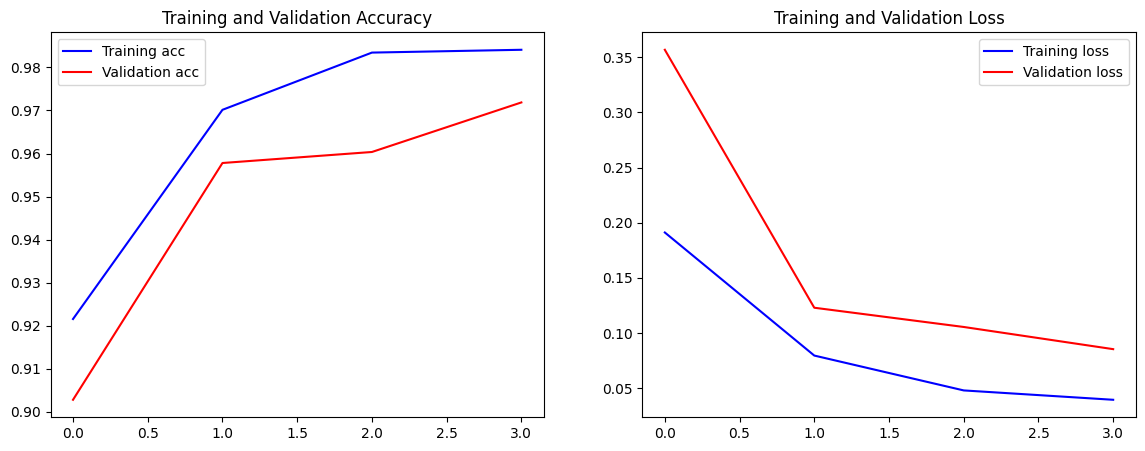

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [22]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2f}")
print(f"Test Loss: {test_loss:.2f}")


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 530ms/step - accuracy: 0.9625 - loss: 0.0825
Test Accuracy: 0.97
Test Loss: 0.09


25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step


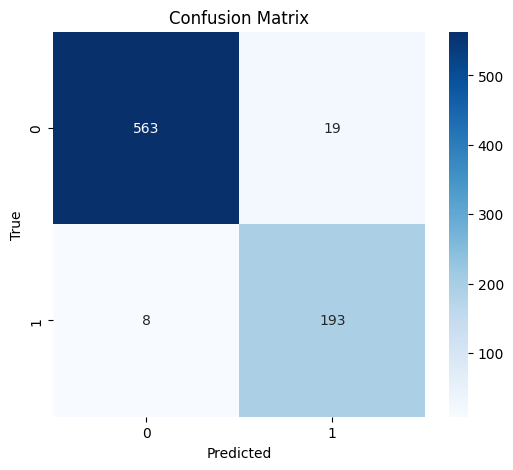


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       582
           1       0.91      0.96      0.93       201

    accuracy                           0.97       783
   macro avg       0.95      0.96      0.96       783
weighted avg       0.97      0.97      0.97       783



In [23]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")  


y_true = y_test  

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Report
print("\nClassification Report:\n", classification_report(y_true, y_pred))


In [24]:
# Create a dummy input with the right shape for your model
dummy_input = tf.random.uniform((1, 224, 224, 3))

# Call the model once with the dummy input to "build" it
_ = model(dummy_input)

# Now you can safely access model.input and model.output
print("Model input:", model.inputs)
print("Model output:", model.outputs)


Model input: [<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, name=keras_tensor_19>]
Model output: [<KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=keras_tensor_24>]


In [25]:
model.save("my_model.h5")

In [29]:
model2 = tf.keras.models.load_model("my_model.h5", compile=False)
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 13,110,785 (50.01 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [28]:
# After training
model.save_weights("my_model.weights.h5")